In [1]:
import pandas as pd
import matplotlib.pyplot as plt

In [2]:
results = pd.DataFrame({
    "Model": [
        "Logistic Regression",
        "Random Forest",
        "Balanced Random Forest",
        "XGBoost"
    ],
    "Accuracy": [
        0.796978,
        0.792434,
        0.665871,
        0.798909
    ],
    "Precision": [
        0.521640,
        0.479371,
        0.334016,
        0.532143
    ],
    "Recall": [
        0.126800,
        0.135105,
        0.632337,
        0.165006
    ],
    "F1": [
        0.204009,
        0.210799,
        0.437129,
        0.251902
    ],
    "ROC_AUC": [
        0.718228,
        0.691749,
        0.717907,
        0.714949
    ]
})

results

,Model,Accuracy,Precision,Recall,F1,ROC_AUC
0,Logistic Regression,0.796978,0.521640,0.126800,0.204009,0.718228
1,Random Forest,0.792434,0.479371,0.135105,0.210799,0.691749
2,Balanced Random Forest,0.665871,0.334016,0.632337,0.437129,0.717907
3,XGBoost,0.798909,0.532143,0.165006,0.251902,0.714949


In [3]:
results.sort_values(
    by="F1",
    ascending=False
)

,Model,Accuracy,Precision,Recall,F1,ROC_AUC
2,Balanced Random Forest,0.665871,0.334016,0.632337,0.437129,0.717907
3,XGBoost,0.798909,0.532143,0.165006,0.251902,0.714949
1,Random Forest,0.792434,0.479371,0.135105,0.210799,0.691749
0,Logistic Regression,0.796978,0.521640,0.126800,0.204009,0.718228


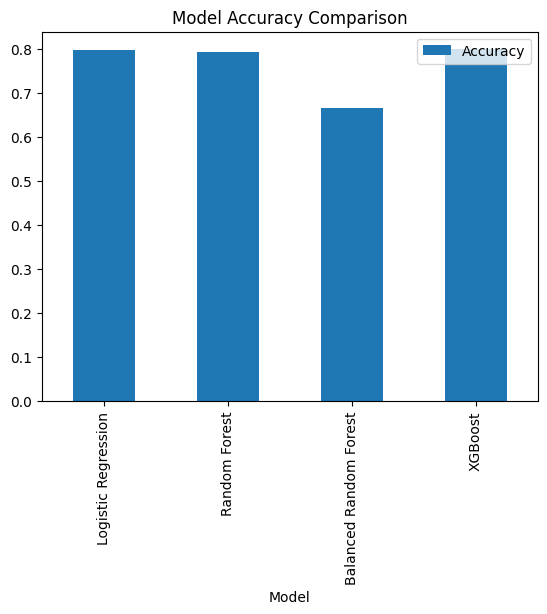

In [4]:
results.plot(
    x="Model",
    y="Accuracy",
    kind="bar"
)

plt.title("Model Accuracy Comparison")
plt.show()

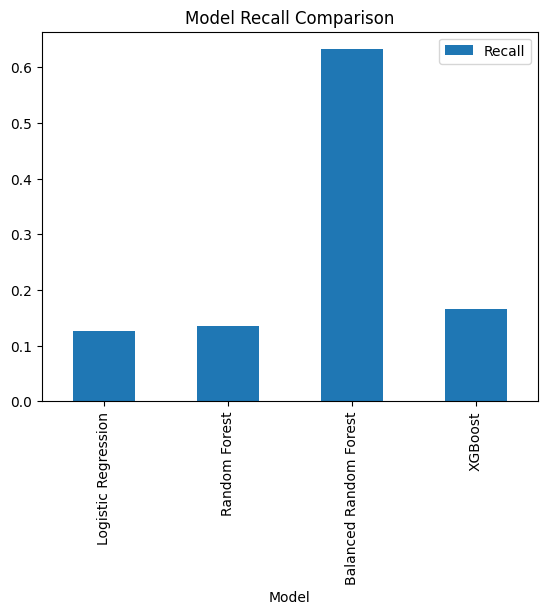

In [5]:
results.plot(
    x="Model",
    y="Recall",
    kind="bar"
)

plt.title("Model Recall Comparison")
plt.show()

## Final Model Selection

After comparing Logistic Regression, Random Forest, Balanced Random Forest, and XGBoost, XGBoost was selected as the final production model.

Reasons:

1. Highest accuracy (79.9%)
2. Highest precision (53.2%)
3. Highest F1 score among high-accuracy models
4. Better recall than Logistic Regression
5. Strong overall balance between business risk and predictive performance

Balanced Random Forest achieved the highest recall and remains useful when maximizing default detection is the primary business objective.

In [6]:
final_recommendation = pd.DataFrame({
    "Selected_Model": ["XGBoost"],
    "Accuracy": [0.798909],
    "Precision": [0.532143],
    "Recall": [0.165006],
    "F1": [0.251902],
    "Reason": [
        "Best overall balance of accuracy, precision, recall and F1 score"
    ]
})

final_recommendation

,Selected_Model,Accuracy,Precision,Recall,F1,Reason
0,XGBoost,0.798909,0.532143,0.165006,0.251902,"Best overall balance of accuracy, precision, r..."


# Model Comparison Summary

Four machine learning models were evaluated for credit risk prediction:

- Logistic Regression
- Random Forest
- Balanced Random Forest
- XGBoost

The models were compared using Accuracy, Precision, Recall, F1 Score, and ROC AUC.

Balanced Random Forest achieved the highest Recall and F1 Score, making it effective at identifying default cases.

XGBoost achieved the highest Accuracy and Precision while maintaining strong ROC AUC performance.

Considering the overall balance between predictive performance and business applicability, XGBoost was selected as the final model for deployment.

# Final Model Selection

XGBoost was selected as the final production model because it delivered:

- Highest Accuracy
- Highest Precision
- Competitive ROC AUC
- Strong overall predictive performance

Although Balanced Random Forest achieved higher Recall, XGBoost provided a better balance between identifying risky borrowers and minimizing false positives.

This balance is important in lending environments where both risk detection and business growth must be considered.

# Feature Importance Analysis

To improve model interpretability, feature importance scores were extracted from the trained XGBoost model.

Feature importance helps identify which borrower characteristics contribute most to lending decisions.

The analysis showed that interest rate, home ownership status, installment amount, loan amount, debt-to-income ratio, and loan grade were among the most influential features used by the model.

These findings align with financial intuition because higher borrowing costs, larger repayment obligations, and weaker borrower profiles are often associated with increased default risk.

In [3]:
import joblib

xgb_model = joblib.load(
    "../models/xgboost_model.pkl"
)

print("Model Loaded Successfully")

Model Loaded Successfully


In [4]:
type(xgb_model)

xgboost.sklearn.XGBClassifier

In [5]:
import pandas as pd

feature_names = [
    'loan_amnt',
    'annual_inc',
    'dti',
    'int_rate',
    'installment',
    'avg_fico',
    'emp_length_num',
    'home_ownership_MORTGAGE',
    'home_ownership_OWN',
    'home_ownership_RENT',
    'purpose_credit_card',
    'purpose_debt_consolidation',
    'purpose_home_improvement',
    'purpose_house',
    'purpose_major_purchase',
    'purpose_medical',
    'purpose_moving',
    'purpose_other',
    'purpose_renewable_energy',
    'purpose_small_business',
    'purpose_vacation',
    'grade_B',
    'grade_C',
    'grade_D',
    'grade_E',
    'grade_F',
    'grade_G'
]

importance_df = pd.DataFrame({
    "Feature": feature_names,
    "Importance": xgb_model.feature_importances_
})

importance_df = importance_df.sort_values(
    by="Importance",
    ascending=False
)

importance_df.head(10)

,Feature,Importance
3,int_rate,0.265253
9,home_ownership_RENT,0.049093
4,installment,0.042533
7,home_ownership_MORTGAGE,0.041503
0,loan_amnt,0.041235
24,grade_E,0.034477
2,dti,0.034373
21,grade_B,0.034208
23,grade_D,0.030532
10,purpose_credit_card,0.030473


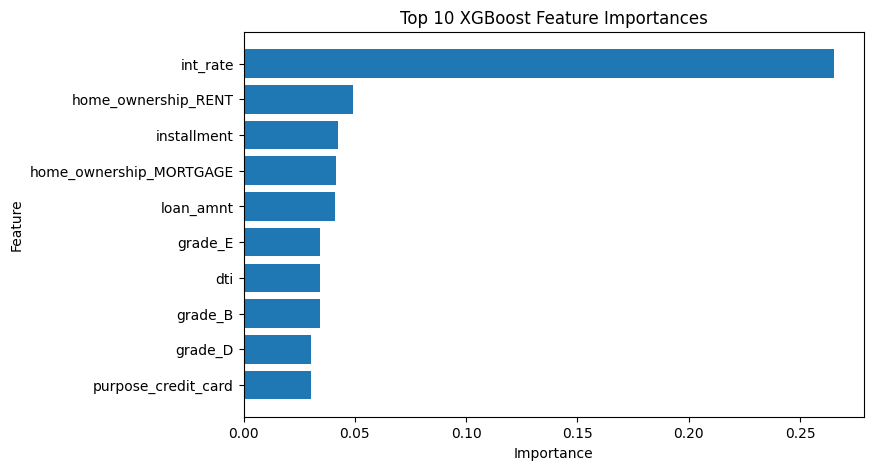

In [6]:
import matplotlib.pyplot as plt

top10 = importance_df.head(10)

plt.figure(figsize=(8,5))

plt.barh(
    top10["Feature"],
    top10["Importance"]
)

plt.xlabel("Importance")
plt.ylabel("Feature")
plt.title("Top 10 XGBoost Feature Importances")

plt.gca().invert_yaxis()

plt.show()

# Business Conclusion

The AI Credit Risk Lending Decision Engine successfully predicts the probability of borrower default using machine learning techniques.

Four machine learning models were evaluated:

- Logistic Regression
- Random Forest
- Balanced Random Forest
- XGBoost

After comparing Accuracy, Precision, Recall, F1 Score, and ROC AUC, XGBoost was selected as the final deployment model due to its strong overall performance and balanced predictive capability.

Feature importance analysis showed that interest rate, home ownership status, loan amount, installment amount, debt-to-income ratio, and loan grade were among the most influential factors affecting borrower risk.

The final model was deployed using Streamlit, allowing users to enter borrower information and receive:

- Default Probability
- Risk Score
- Risk Category
- Lending Decision
- Decision Explanation

This project demonstrates the complete machine learning lifecycle, including data preprocessing, feature engineering, model training, model evaluation, explainable AI, and deployment.

The solution can help lenders make faster, more consistent, and data-driven credit risk decisions.